In [ ]:


from pyspark.sql import SparkSession, functions as F

# BUILDING A SPARK SESSION TO CONNECT TO A REMOTE SPARK CLUSTER

spark = (
    SparkSession.builder
    .appName("RemoteApp")
    .config("spark.connect.address", "sc://138.199.214.206:15002")
    # .config("spark.local.dir", "D:/spark-temp")
    .getOrCreate()
)
spark.conf.set("spark.sql.shuffle.partitions", "200")



In [ ]:


olist = spark.read.parquet("final_table.parquet") 
olist.createOrReplaceTempView("olist")


final_olist_orders_df = spark.read.parquet("orders_table.parquet")
final_olist_customer_df= spark.read.parquet("customers_table.parquet")
final_olist_products_df = spark.read.parquet("products_table.parquet")
final_olist_sellers_df = spark.read.parquet("sellers_table.parquet")
final_olist_order_items_df = spark.read.parquet("order_items_table.parquet")
final_olist_payment_df = spark.read.parquet("order_payments_table.parquet")
final_olist_reviews_df = spark.read.parquet("order_reviews_table.parquet")
final_olist_geolocation_df = spark.read.parquet("geographies_table.parquet")

In [214]:
olist.printSchema()


root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- purchase_date: string (nullable = true)
 |-- purchase_time: string (nullable = true)
 |-- approved_date: string (nullable = true)
 |-- approved_time: string (nullable = true)
 |-- delivered_date: string (nullable = true)
 |-- delivered_time: string (nullable = true)
 |-- estimated_date: string (nullable = true)
 |-- estimated_time: string (nullable = true)
 |-- duration_days: integer (nullable = true)
 |-- duration_hours: long (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- is_weekend_delivery: boolean (nullable = true)
 |-- gross_value: double (nullable = true)
 |-- shipping_date: string (nullable = true)
 |-- shipping_time: string (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)
 |-- pr

In [215]:
from pyspark.sql import functions as F

order_status_counts = (
    olist.groupBy("seller_id", "order_status")
         .agg(F.countDistinct("order_id").alias("cnt"))
         .groupBy("seller_id")
         .pivot("order_status")
         .sum("cnt")
         .na.fill(0)
)
order_status_counts.show(3)


+--------------------+--------+--------+---------+--------+----------+-------+-----------+
|           seller_id|Approved|Canceled|Delivered|Invoiced|Processing|Shipped|Unavailable|
+--------------------+--------+--------+---------+--------+----------+-------+-----------+
|a3082f442524a1be4...|       0|       0|        3|       0|         0|      0|          0|
|4d600e08ecbe08258...|       0|       0|        7|       1|         0|      0|          0|
|da7039f29f90ce5b4...|       0|       0|       17|       0|         0|      0|          0|
+--------------------+--------+--------+---------+--------+----------+-------+-----------+
only showing top 3 rows



In [216]:

# spark.sparkContext.setLogLevel("WARN")   # or "ERROR"

# # 1️⃣  See the full seller_id values before you copy-paste them
# order_status_counts.show(20, truncate=False)

# # 2️⃣  Copy one complete seller_id string (40 hex chars)
# sid = "4d600e08ecbe08258b0acee2752745ec"   # example, paste the *whole* string

# olist.filter(F.col("seller_id") == sid) \
#      .groupBy("order_status") \
#      .agg(F.countDistinct("order_id").alias("cnt")) \
#      .orderBy("cnt", ascending=False) \
#      .show()


# review_score = (
#     olist.groupBy("seller_id")
#          .agg(F.round(F.avg("review_score"), 2).alias("average_review_score"))
# )

# review_score.show()

In [217]:
olist.select(F.min("purchase_date")).show()
# → 2016-09-04 21:15:19


# Maximum purchase date (used for recency)
max_date = olist.agg(F.max("purchase_date")).first()[0]

abt_core = (
    olist.groupBy("seller_id")
         .agg(
             F.first("seller_state").alias("seller_state"),
             F.countDistinct("order_id").alias("total_orders"),
             F.count("product_id").alias("total_products"),
             F.count("product_id")/F.countDistinct("order_id")
                 .alias("products_per_order"),
             F.countDistinct("customer_id").alias("total_buyers"),
             F.sum("gross_value").alias("sales_value"),
             (F.sum("gross_value")/F.countDistinct("order_id"))
                 .alias("avg_ticket_size"),
             F.min("purchase_date").alias("first_purchase"),
             F.max("purchase_date").alias("last_purchase"),
             F.datediff(F.lit(max_date), F.max("purchase_date"))
                 .alias("recency_days"),
             F.avg(
                 F.datediff("delivered_date",
                            "estimated_date")
             ).alias("delivery_delay_days"),
             (F.countDistinct("order_id") /
              (F.datediff(F.lit(max_date),
                          F.min("purchase_date"))/30.0)
             ).alias("order_frequency_per_month")
         )
)
abt_core.orderBy(F.col("first_purchase")).show(5, truncate=False)
# now you’ll see the seller whose first_purchase == 2016-09-04



+------------------+
|min(purchase_date)|
+------------------+
|        2016-09-04|
+------------------+



+--------------------------------+------------+------------+--------------+-----------------------------------------------------------+------------+------------------+------------------+--------------+-------------+------------+-------------------+-------------------------+
|seller_id                       |seller_state|total_orders|total_products|(count(product_id) / count(order_id) AS products_per_order)|total_buyers|sales_value       |avg_ticket_size   |first_purchase|last_purchase|recency_days|delivery_delay_days|order_frequency_per_month|
+--------------------------------+------------+------------+--------------+-----------------------------------------------------------+------------+------------------+------------------+--------------+-------------+------------+-------------------+-------------------------+
|1554a68530182680ad5c8b042c3ab563|MG          |243         |243           |1.0                                                        |243         |33638.37          |138.4295

In [218]:
df_ORDER_STATUS = spark.sql("""
SELECT seller_id
	,SUM(CASE WHEN order_status = 'Delivered' THEN 1 ELSE 0 END) AS delivered
	,SUM(CASE WHEN order_status = 'Shipped' THEN 1 ELSE 0 END) AS shipped
	,SUM(CASE WHEN order_status = 'Approved' THEN 1 ELSE 0 END) AS approved
	,SUM(CASE WHEN order_status = 'Canceled' THEN 1 ELSE 0 END) AS canceled
	,SUM(CASE WHEN order_status = 'Invoiced' THEN 1 ELSE 0 END) AS invoiced
	,SUM(CASE WHEN order_status = 'Created' THEN 1 ELSE 0 END) AS created
	,SUM(CASE WHEN order_status = 'Unavailable' THEN 1 ELSE 0 END) AS unavailable
	,SUM(CASE WHEN order_status = 'Processing' THEN 1 ELSE 0 END) AS processing
FROM (
	SELECT seller_id, order_id, order_status
	FROM olist
	GROUP BY seller_id, order_id, order_status
)
GROUP BY seller_id
""")

df_ORDER_STATUS.createOrReplaceTempView("df_ORDER_STATUS")
df_ORDER_STATUS.show(5, truncate=False)

+--------------------------------+---------+-------+--------+--------+--------+-------+-----------+----------+
|seller_id                       |delivered|shipped|approved|canceled|invoiced|created|unavailable|processing|
+--------------------------------+---------+-------+--------+--------+--------+-------+-----------+----------+
|9c068d10aca38e85c50202e17b4a7e88|14       |0      |0       |0       |0       |0      |0          |0         |
|0ea22c1cfbdc755f86b9b54b39c16043|226      |2      |0       |0       |1       |0      |0          |0         |
|a49928bcdf77c55c6d6e05e09a9b4ca5|93       |2      |0       |0       |0       |0      |0          |0         |
|ff063b022a9a0aab91bad2c9088760b7|94       |0      |0       |0       |0       |0      |0          |0         |
|791cfcfe22fe4a771ece27f90017da92|1        |0      |0       |0       |1       |0      |0          |0         |
+--------------------------------+---------+-------+--------+--------+--------+-------+-----------+----------+
o

In [219]:
df_REVIEW_SCORE = spark.sql("""
SELECT seller_id,
	   AVG(review_score) AS review_score
FROM (
	SELECT seller_id,
		   order_id,
		   review_score
	FROM olist
	GROUP BY seller_id, order_id, review_score
)
GROUP BY seller_id
""")

df_REVIEW_SCORE.createOrReplaceTempView("df_REVIEW_SCORE")
df_REVIEW_SCORE.show(5, truncate=False)

+--------------------------------+------------------+
|seller_id                       |review_score      |
+--------------------------------+------------------+
|0ea22c1cfbdc755f86b9b54b39c16043|4.135371179039302 |
|e63e8bfa530fb16910dd6956e592bb81|4.073170731707317 |
|ec8879960bd2221d5c32f8e12f7da711|4.0               |
|da7039f29f90ce5b4846ffc0fcc93beb|4.529411764705882 |
|a49928bcdf77c55c6d6e05e09a9b4ca5|2.9368421052631577|
+--------------------------------+------------------+
only showing top 5 rows



In [220]:
df_temp = spark.sql(f"""
SELECT seller_id,
	   first_value(seller_state) AS seller_state,
	   COUNT(DISTINCT(order_id)) AS qtd_order,
	   COUNT(product_id) AS number_of_products,
	   COUNT(product_id)/COUNT(DISTINCT(order_id)) AS qtd_product_order,
	   COUNT(DISTINCT(customer_id)) AS number_of_buyers,
	   SUM(gross_value) AS sale_value,
	   SUM(gross_value)/COUNT(DISTINCT(order_id)) AS ticket_size,
	   MIN(purchase_date) AS first_order_purchase,
	   MAX(purchase_date) AS last_order_purchase,
	   DATEDIFF('{max_date}', MAX(purchase_date)) AS recency,
	   AVG(DATEDIFF(delivered_date, estimated_date)) AS days_delay_delivery,
	   COUNT(DISTINCT(order_id))/(DATEDIFF('{max_date}', MIN(purchase_date)) / 30.0) AS frequency
FROM olist
GROUP BY seller_id
""")
df_temp.createOrReplaceTempView("df_temp")
df_temp.show(5, truncate=False)

+--------------------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+
|seller_id                       |seller_state|qtd_order|number_of_products|qtd_product_order|number_of_buyers|sale_value        |ticket_size       |first_order_purchase|last_order_purchase|recency|days_delay_delivery|frequency      |
+--------------------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+
|0015a82c2db000af6aaaf3ae2ecb0532|SP          |3        |3                 |1.0              |3               |2748.06           |916.02            |2017-09-26          |2017-10-18         |320    |-16.333333333333332|0.263157894737 |
|001cca7ae9ae17fb1caed9dfb1094831|ES          |200      |200

In [221]:
unique_values = olist.select('product_category_en').distinct()

# Show the unique values
unique_values_list = [row['product_category_en'] for row in unique_values.collect()]
print(unique_values_list)


df_product_category = spark.sql("""
SELECT seller_id,
	   product_category_en
FROM olist
GROUP BY seller_id, product_category_en
""")

df_product_category.createOrReplaceTempView("df_product_category")

df_product_category.show(5, truncate=False)

['ARTS_AND_CRAFTMANSHIP', 'COMPUTERS_ACCESSORIES', 'TABLETS_PRINTING_IMAGE', 'INDUSTRY_COMMERCE_AND_BUSINESS', 'HOME_APPLIANCES', 'AIR_CONDITIONING', 'FASHION_SHOES', 'AGRO_INDUSTRY_AND_COMMERCE', 'BOOKS_GENERAL_INTEREST', 'COSTRUCTION_TOOLS_GARDEN', 'SMALL_APPLIANCES', 'FASHION_MALE_CLOTHING', 'FASHION_UNDERWEAR_BEACH', 'HOME_CONFORT', 'PET_SHOP', 'COMPUTERS', 'TOYS', 'AUTO', 'SIGNALING_AND_SECURITY', 'FASHION_CHILDRENS_CLOTHES', 'MARKET_PLACE', 'CINE_PHOTO', 'FOOD', 'SMALL_APPLIANCES_HOME_OVEN_AND_COFFEE', 'Unknown', 'CONSTRUCTION_TOOLS_CONSTRUCTION', 'FASHIO_FEMALE_CLOTHING', 'FURNITURE_LIVING_ROOM', 'HOUSEWARES', 'MUSIC', 'CONSTRUCTION_TOOLS_SAFETY', 'DVDS_BLU_RAY', 'CONSTRUCTION_TOOLS_LIGHTS', 'LUGGAGE_ACCESSORIES', 'ART', 'KITCHEN_DINING_LAUNDRY_GARDEN_FURNITURE', 'CHRISTMAS_SUPPLIES', 'FOOD_DRINK', 'ELECTRONICS', 'STATIONERY', 'HEALTH_BEAUTY', 'TELEPHONY', 'HOME_CONSTRUCTION', 'WATCHES_GIFTS', 'PERFUMERY', 'BED_BATH_TABLE', 'OFFICE_FURNITURE', 'DRINKS', 'BABY', 'CDS_DVDS_MUSICAL

In [222]:
# df_product_category_pivot is already defined and available

# Build the ABT with correct column names
# product_category_cols_str is already defined

sql_query = f"""
SELECT temp.seller_id,
       temp.seller_state,
       temp.qtd_order,
       temp.number_of_products,
       temp.qtd_product_order,
       temp.number_of_buyers,
       temp.sale_value,
       temp.ticket_size,
       temp.first_order_purchase,
       temp.last_order_purchase,
       temp.recency,
       temp.days_delay_delivery,
       temp.frequency,
       order.delivered,
       order.shipped,
       order.approved,
       order.canceled,
       order.invoiced,
       order.created,
       order.unavailable,
       order.processing,
       score.review_score,
       {product_category_cols_str}
FROM df_temp temp
LEFT JOIN df_ORDER_STATUS `order`
  ON temp.seller_id = order.seller_id
LEFT JOIN df_REVIEW_SCORE score
  ON temp.seller_id = score.seller_id
LEFT JOIN df_product_category_pivot product
  ON temp.seller_id = product.seller_id
"""

df_temp_abt = spark.sql(sql_query)
df_temp_abt.createOrReplaceTempView("df_temp_abt")
df_temp_abt.show(5, truncate=False)


+--------------------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---

In [223]:
# df_temp_abt is already defined and available with correct columns

# Create the schema if it does not exist
spark.sql("CREATE SCHEMA IF NOT EXISTS olist")

# Drop the table if it exists
spark.sql("DROP TABLE IF EXISTS olist.abt_temp")

# Save df_temp_abt as a new table
df_temp_abt.write.saveAsTable("olist.abt_temp")

# StringIndexer is already imported and available as StringIndexer
indexer = StringIndexer(inputCol="seller_state", outputCol="seller_state_index").setHandleInvalid("skip")
df_temp_abt2 = indexer.fit(df_temp_abt).transform(df_temp_abt)
df_temp_abt2.createOrReplaceTempView("df_temp_abt2")
df_temp_abt2.show(5, truncate=False)

# Drop the table if it exists
spark.sql("DROP TABLE IF EXISTS olist.abt")

# Save the DataFrame as a new table using DataFrame API
df_temp_abt2.write.saveAsTable("olist.abt")

+--------------------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---

<!-- FEATURE ENGINEERING  -->

In [224]:
df_abt = df_temp_abt2.drop('FIRST_ORDER_PURCHASE_TIMESTAMP', 'LAST_ORDER_PURCHASE_TIMESTAMP')
df_abt.show()
from pyspark.sql.functions import col, countDistinct, year, month, dayofmonth, concat, lit, isnan, when, count, desc
df_abt = df_abt.filter((df_abt.seller_id != 'null'))
df_abt.select([count(when(col(c).isNull(), c)).alias(c) for c in df_abt.columns]).show()
df_abt.printSchema()

+--------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---------------

+---------+------------+---------+------------------+-----------------+----------------+----------+-----------+--------------------+-------------------+-------+-------------------+---------+---------+-------+--------+--------+--------+-------+-----------+----------+------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---------------------+-------------------------------

In [225]:
df_abt.columns

from pyspark.ml.feature import VectorAssembler

# Use the correct lowercase column names as in df_abt
input_cols = [
	"qtd_order", "number_of_products", "qtd_product_order", "number_of_buyers", "sale_value", "ticket_size",
	"recency", "days_delay_delivery", "frequency", "delivered", "shipped", "approved", "canceled", "invoiced",
	"created", "unavailable", "processing", "review_score",
	"ART", "FLOWERS", "HOME_CONSTRUCTION", "FASHION_MALE_CLOTHING", "KITCHEN_DINING_LAUNDRY_GARDEN_FURNITURE",
	"SMALL_APPLIANCES", "LA_CUISINE", "BED_BATH_TABLE", "SIGNALING_AND_SECURITY", "OFFICE_FURNITURE", "COMPUTERS",
	"WATCHES_GIFTS", "AUTO", "FASHION_BAGS_ACCESSORIES", "CONSTRUCTION_TOOLS_LIGHTS", "COOL_STUFF",
	"CDS_DVDS_MUSICALS", "FOOD", "COMPUTERS_ACCESSORIES", "PERFUMERY", "PET_SHOP", "STATIONERY", "FURNITURE_DECOR",
	"DRINKS", "CONSTRUCTION_TOOLS_SAFETY", "TELEPHONY", "HOME_CONFORT", "FURNITURE_MATTRESS_AND_UPHOLSTERY",
	"AGRO_INDUSTRY_AND_COMMERCE", "PARTY_SUPPLIES", "CINE_PHOTO", "BOOKS_TECHNICAL", "HOME_APPLIANCES_2", "MUSIC",
	"COSTRUCTION_TOOLS_GARDEN", "CHRISTMAS_SUPPLIES", "AUDIO", "FASHIO_FEMALE_CLOTHING", "AIR_CONDITIONING",
	"MARKET_PLACE", "HEALTH_BEAUTY", "FASHION_SHOES", "FASHION_UNDERWEAR_BEACH", "HOUSEWARES", "HOME_APPLIANCES",
	"COSTRUCTION_TOOLS_TOOLS", "FURNITURE_LIVING_ROOM", "ARTS_AND_CRAFTMANSHIP", "FIXED_TELEPHONY", "ELECTRONICS",
	"DIAPERS_AND_HYGIENE", "BOOKS_IMPORTED", "BABY", "HOME_COMFORT_2", "FASHION_CHILDRENS_CLOTHES",
	"LUGGAGE_ACCESSORIES", "SMALL_APPLIANCES_HOME_OVEN_AND_COFFEE", "FOOD_DRINK", "FURNITURE_BEDROOM",
	"TABLETS_PRINTING_IMAGE", "FASHION_SPORT", "TOYS", "CONSOLES_GAMES", "GARDEN_TOOLS", "SPORTS_LEISURE",
	"INDUSTRY_COMMERCE_AND_BUSINESS", "BOOKS_GENERAL_INTEREST", "CONSTRUCTION_TOOLS_CONSTRUCTION", "DVDS_BLU_RAY",
	"MUSICAL_INSTRUMENTS", "SECURITY_AND_SERVICES", "seller_state_index"
]

# Fill nulls in all input columns with 0
df_abt_filled = df_abt.fillna(0, subset=input_cols)

Training_data = VectorAssembler().setInputCols(input_cols).setOutputCol('features').transform(df_abt_filled)
display(Training_data)

scaler = StandardScaler(inputCol='features', outputCol='scaledFeatures')
Scaled_training_data = scaler.fit(Training_data).transform(Training_data)
Scaled_training_data.show()



DataFrame[seller_id: string, seller_state: string, qtd_order: bigint, number_of_products: bigint, qtd_product_order: double, number_of_buyers: bigint, sale_value: double, ticket_size: double, first_order_purchase: string, last_order_purchase: string, recency: int, days_delay_delivery: double, frequency: decimal(38,12), delivered: bigint, shipped: bigint, approved: bigint, canceled: bigint, invoiced: bigint, created: bigint, unavailable: bigint, processing: bigint, review_score: double, AGRO_INDUSTRY_AND_COMMERCE: bigint, AIR_CONDITIONING: bigint, ART: bigint, ARTS_AND_CRAFTMANSHIP: bigint, AUDIO: bigint, AUTO: bigint, BABY: bigint, BED_BATH_TABLE: bigint, BOOKS_GENERAL_INTEREST: bigint, BOOKS_IMPORTED: bigint, BOOKS_TECHNICAL: bigint, CDS_DVDS_MUSICALS: bigint, CHRISTMAS_SUPPLIES: bigint, CINE_PHOTO: bigint, COMPUTERS: bigint, COMPUTERS_ACCESSORIES: bigint, CONSOLES_GAMES: bigint, CONSTRUCTION_TOOLS_CONSTRUCTION: bigint, CONSTRUCTION_TOOLS_LIGHTS: bigint, CONSTRUCTION_TOOLS_SAFETY: big

+--------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---------------

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


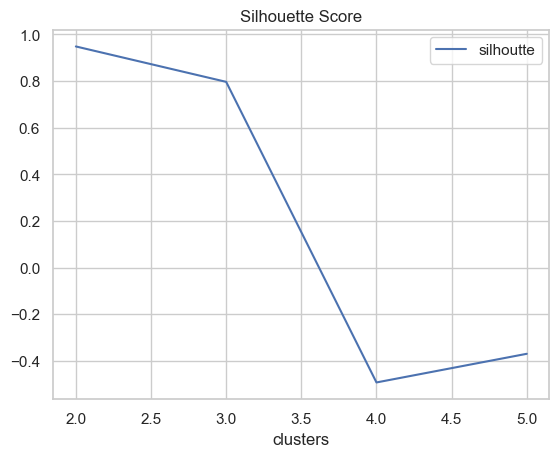

<Axes: title={'center': 'Silhouette Score'}, xlabel='clusters'>

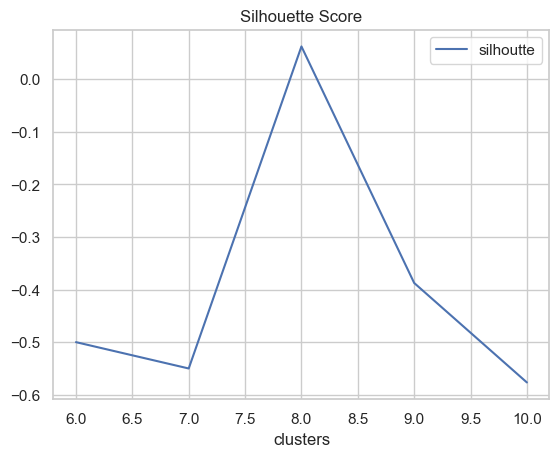

In [226]:
%pip install matplotlib
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd
import matplotlib.pyplot as plt

silhouettes = []
clusters = [2, 3, 4, 5]
for n_clusters in clusters:
    kmeans = KMeans(featuresCol='scaledFeatures', k=n_clusters, seed=666)
    model  = kmeans.fit(Scaled_training_data)
    predictor = model.transform(Scaled_training_data)
    evaluator = ClusteringEvaluator()
    silhoutte_value = evaluator.evaluate(predictor)
    silhouettes.append(silhoutte_value)

kmeans_df = pd.DataFrame({'clusters': clusters, 'silhoutte': silhouettes})
kmeans_df

kmeans_df.plot(x='clusters', y='silhoutte', title='Silhouette Score')
plt.show()

# According to the silhouette score analysis, the best division is with 2 clusters, the second best is with 3 clusters and the third best is with 6 clusters.

silhouettes = []
clusters = [6, 7, 8, 9,10]
for n_clusters in clusters:
    kmeans = KMeans(featuresCol='scaledFeatures', k=n_clusters, seed=666)
    model  = kmeans.fit(Scaled_training_data)
    predictor = model.transform(Scaled_training_data)
    evaluator = ClusteringEvaluator()
    silhoutte_value = evaluator.evaluate(predictor)
    silhouettes.append(silhoutte_value)
kmeans_df = pd.DataFrame({'clusters': clusters, 'silhoutte': silhouettes})
kmeans_df

kmeans_df.plot(x='clusters', y='silhoutte', title='Silhouette Score')


# According to the silhouette score analysis, the best division is with 2 clusters, the second best is with 3 clusters and the third best is with 6 clusters.



In [227]:
kmeans = KMeans(featuresCol='scaledFeatures', k=2, seed=666)
model  = kmeans.fit(Scaled_training_data)
predictor2 = model.transform(Scaled_training_data)
predictor2.show()



+--------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---------------

In [228]:
# Save predictor2 as a Spark SQL table using DataFrame API (works without Hive support)
predictor2.write.mode("overwrite").saveAsTable("olist.predictor_categoryk2")

centers = model.clusterCenters()
print("Cluster Centers: ")
for center in centers:
    print(center)

Cluster Centers: 
[ 0.19033136  0.19033136  0.          0.19033136  0.2160594   0.60964761
  0.86533555 -1.40710136  0.31041571  0.18869228  0.14030194  0.02613933
  0.21982141  0.11184435  0.          0.02614993  0.16771464  3.47454883
  0.09737403  0.02134613  0.14024616  0.05649061  0.12662609  0.17796421
  0.02613933  0.24255477  0.10544007  0.09877944  0.04934482  0.15329132
  0.34719622  0.17365576  0.10084885  0.26326646  0.          0.11213308
  0.28605987  0.22722365  0.20726679  0.22037948  0.35122081  0.10196587
  0.09737403  0.1867932   0.06632167  0.03308002  0.09240657  0.06413207
  0.05939408  0.09461555  0.11931377  0.06551849  0.09850274  0.07190079
  0.06505111  0.05267274  0.11479549  0.12246575  0.41547334  0.05260702
  0.05551292  0.41318467  0.11558208  0.07951474  0.13072709  0.0613918
  0.09845048  0.18861938  0.04578838  0.04894189  0.26651728  0.02773394
  0.03697858  0.12913013  0.05738948  0.1002485   0.08894612  0.02265201
  0.04682021  0.28403337  0.122020

In [229]:

kmeans = KMeans(featuresCol='scaledFeatures', k=3, seed=666)
model  = kmeans.fit(Scaled_training_data)
predictor3 = model.transform(Scaled_training_data)
predictor3.show()

# Register as temp view
predictor3.createOrReplaceTempView('predictor_category3')

# Drop the table if it exists and save as a new table using DataFrame API
spark.sql("DROP TABLE IF EXISTS olist.predictor_category3")
predictor3.write.mode("overwrite").saveAsTable("olist.predictor_category3")

centers = model.clusterCenters()
print("Cluster Centers: ")
for center in centers:
    print(center)


+--------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---------------

Cluster Centers: 
[ 9.91667635  9.91667635  0.          9.91667635  8.66860528  0.40685005
  0.05831668 -1.3806014   8.93126733  9.92281392  8.03964376  0.
  3.84384147  2.37768106  0.          1.87158763  0.71132304  3.51310656
  0.4496257   0.          0.32910222  0.73511163  0.73982122  0.2626217
  0.          0.58847429  1.1915521   1.36834554  0.          1.605553
  1.15915241  0.2701911   1.31234473  1.70519063  0.          1.07006997
  0.98668498  1.23514338  0.46722457  1.03768911  0.88459972  0.45611518
  0.4496257   1.11408801  0.59334212  0.          0.45611518  0.
  0.          0.          0.          0.          0.          0.
  1.77363835  0.83774739  0.37345804  0.70120389  1.04566225  0.
  0.          0.53283275  0.38476162  0.54199844  0.35985864  0.
  0.38087794  0.89998388  0.          0.          1.06465242  1.32330495
  0.          0.31328908  0.          0.46289861  0.          0.
  0.          0.87247529  0.59207859  0.90104692  1.31594733  0.49346861
  0.3631154

In [230]:
kmeans = KMeans(featuresCol='scaledFeatures', k=6, seed=666)
model  = kmeans.fit(Scaled_training_data)
predictor6 = model.transform(Scaled_training_data)
predictor6.show()

# Register as temp view
predictor6.createOrReplaceTempView('predictor_category6')

# Drop the table if it exists and save as a new table using DataFrame API
spark.sql("DROP TABLE IF EXISTS olist.predictor_category6")
predictor6.write.mode("overwrite").saveAsTable("olist.predictor_category6")

centers = model.clusterCenters()
print("Cluster Centers: ")
for center in centers:
    print(center)


+--------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---------------

Cluster Centers: 
[ 1.24010804  1.24010804  0.          1.24010804  1.18522263  0.47660406
  0.32143169 -1.51825265  1.39977885  1.23317047  0.98449056  0.14938177
  1.04924738  0.89230844  0.          0.          0.3975836   3.50006491
  0.28721337  0.12198949  0.42044998  0.11739425  0.20675612  0.3355167
  0.          0.57952411  0.31714315  0.03641984  0.28199719  0.74783362
  0.91398947  0.45305808  0.17464664  1.48409937  0.21122349  0.5126571
  1.49690991  0.50955535  0.48498976  0.89485889  0.51797854  0.07283969
  0.64623009  1.35215549  0.28426276  0.09452332  0.21851906  0.24433587
  0.62228289  0.12477962  0.03171431  0.44931237  0.33775579  0.20545035
  0.95594387  0.          0.32801828  0.81185013  0.67838829  0.
  0.          0.80836603  0.30722411  0.17310977  0.20113772  0.06378975
  0.97319381  1.3114784   0.1495273   0.31965089  0.94928134  0.10566313
  0.21132627  0.70043338  0.          0.07392297  0.04420103  0.51780956
  0.13378475  1.01711378  1.22918216  0.618

In [231]:
from pyspark.ml.clustering import GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
gmm = GaussianMixture().setK(3).setSeed(666)
model = gmm.fit(Scaled_training_data )
predictor = model.transform(Scaled_training_data )
predictor.show()

model.gaussiansDF.show()

+--------------------+------------+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+---------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---------------

In [232]:
%pip install scikit-learn

import pandas as pd
Scaled_training_data2 = Scaled_training_data.drop('SELLER_ID', 'SELLER_STATE', 'features', 'scaledFeatures')
Scaled_training_data2 = Scaled_training_data2.toPandas()
from sklearn.preprocessing import StandardScaler



Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [233]:
# Use the already imported StandardScaler and pandas
# Scaled_training_data2 is a pandas DataFrame, Scaled_training_data_norm is a numpy array

# Use all_fit_cols for correct column names (matches shape of Scaled_training_data_norm)
Scaled_training_data_norm_df = pd.DataFrame(Scaled_training_data_norm, columns=all_fit_cols)
Scaled_training_data_norm_df.head()


,qtd_order,number_of_products,qtd_product_order,number_of_buyers,sale_value,ticket_size,recency,days_delay_delivery,frequency,delivered,...,INDUSTRY_COMMERCE_AND_BUSINESS,BOOKS_GENERAL_INTEREST,CONSTRUCTION_TOOLS_CONSTRUCTION,DVDS_BLU_RAY,MUSICAL_INSTRUMENTS,SECURITY_AND_SERVICES,seller_state_index,Unknown,first_order_purchase,last_order_purchase
0,-0.278519,-0.278519,0.0,-0.278519,-0.131760,2.135796,1.056929,-0.572651,-0.379114,-0.276178,...,-0.097398,-0.133454,-0.207171,-0.057017,-0.152347,-0.025466,-0.557563,-0.302044,0.0,0.0
1,1.621196,1.621196,0.0,1.621196,1.646132,-0.177727,-0.530618,-0.154081,1.099558,1.605743,...,-0.097398,-0.133454,4.826926,-0.057017,-0.152347,-0.025466,2.732379,-0.302044,0.0,0.0
2,-0.297806,-0.297806,0.0,-0.297806,-0.302755,0.197017,-0.685210,1.408251,-0.255625,-0.305583,...,-0.097398,-0.133454,-0.207171,-0.057017,-0.152347,-0.025466,1.087408,-0.302044,0.0,0.0
3,0.174712,0.174712,0.0,0.174712,-0.191206,-0.491713,0.010456,0.438013,0.199645,0.174699,...,-0.097398,-0.133454,-0.207171,-0.057017,-0.152347,-0.025466,-0.557563,-0.302044,0.0,0.0
4,-0.297806,-0.297806,0.0,-0.297806,-0.311618,-0.187580,0.712069,-1.866302,-0.400762,-0.295781,...,-0.097398,-0.133454,-0.207171,-0.057017,-0.152347,-0.025466,1.909894,3.310776,0.0,0.0


<!-- DBSCAN -->

In [234]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 40, 50, 60]

for num_eps in eps:
    clusters = DBSCAN(eps=num_eps)
    prediction = clusters.fit_predict(Scaled_training_data_norm)
    
    score = silhouette_score(Scaled_training_data_norm, prediction)
    
    print('#{} of eps, silhoutte_score: {}%'.format(num_eps, round(score*100, 2)))

#1 of eps, silhoutte_score: -24.66%
#2 of eps, silhoutte_score: -6.66%
#3 of eps, silhoutte_score: 3.08%
#4 of eps, silhoutte_score: 7.99%
#5 of eps, silhoutte_score: 12.2%
#6 of eps, silhoutte_score: 19.07%
#7 of eps, silhoutte_score: 21.61%
#8 of eps, silhoutte_score: 25.04%
#9 of eps, silhoutte_score: 27.78%
#10 of eps, silhoutte_score: 32.64%
#15 of eps, silhoutte_score: 44.61%
#20 of eps, silhoutte_score: 54.52%
#30 of eps, silhoutte_score: 74.6%
#40 of eps, silhoutte_score: 84.76%
#50 of eps, silhoutte_score: 84.76%
#60 of eps, silhoutte_score: 84.76%


In [235]:
db = DBSCAN(eps=40)
Scaled_training_data2['db40'] = db.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['db40'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['db40'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table


,#,%
db40,,
0,3085,99.967596
-1,1,0.032404


In [236]:
db = DBSCAN(eps=20)
Scaled_training_data2['db20'] = db.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['db20'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['db20'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table

,#,%
db20,,
0,3038,98.444588
-1,42,1.360985
1,6,0.194426


In [237]:
db = DBSCAN(eps=18)
Scaled_training_data2['db18'] = db.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['db18'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['db18'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table

,#,%
db18,,
0,3001,97.245625
-1,58,1.879456
2,8,0.259235
3,7,0.226831
1,6,0.194426
4,6,0.194426


In [238]:
Scaled_training_data2.nunique()

qtd_order              242
number_of_products     242
qtd_product_order        1
number_of_buyers       242
sale_value            3062
                      ... 
WATCHES_GIFTS            2
seller_state_index      23
db40                     2
db20                     3
db18                     6
Length: 96, dtype: int64

<!-- MeanShift Clustering -->

In [239]:
from sklearn.cluster import MeanShift
bdw = [1,2, 3, 4, 5, 10, 15, 20, 30, 40, 50]

for num_bdw in bdw:
    clusters = MeanShift(bandwidth=num_bdw)
    prediction = clusters.fit_predict(Scaled_training_data_norm)    
    
    score = silhouette_score(Scaled_training_data_norm, prediction)
    
    print('With {} bandwidth, silhoutte_score: {}%'.format(num_bdw, round(score*100,2)))

With 1 bandwidth, silhoutte_score: 9.54%
With 2 bandwidth, silhoutte_score: 16.12%
With 3 bandwidth, silhoutte_score: 17.51%
With 4 bandwidth, silhoutte_score: 10.22%
With 5 bandwidth, silhoutte_score: 9.88%
With 10 bandwidth, silhoutte_score: 29.5%
With 15 bandwidth, silhoutte_score: 44.95%
With 20 bandwidth, silhoutte_score: 54.78%
With 30 bandwidth, silhoutte_score: 68.37%
With 40 bandwidth, silhoutte_score: 73.37%
With 50 bandwidth, silhoutte_score: 84.76%


In [240]:
ms = MeanShift(bandwidth=50)
Scaled_training_data2['ms50'] = ms.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['ms50'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['ms50'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table

,#,%
ms50,,
0,3085,99.967596
1,1,0.032404


In [241]:
ms = MeanShift(bandwidth=40)
Scaled_training_data2['ms40'] = ms.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['ms40'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['ms40'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table

,#,%
ms40,,
0,3083,99.902787
1,2,0.064809
2,1,0.032404


In [242]:
ms = MeanShift(bandwidth=35)
Scaled_training_data2['ms35'] = ms.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['ms35'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['ms35'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table

,#,%
ms35,,
0,3077,99.708360
3,3,0.097213
1,2,0.064809
2,2,0.064809
5,1,0.032404
4,1,0.032404


In [243]:
Scaled_training_data2.nunique()

qtd_order              242
number_of_products     242
qtd_product_order        1
number_of_buyers       242
sale_value            3062
                      ... 
db20                     3
db18                     6
ms50                     2
ms40                     3
ms35                     6
Length: 99, dtype: int64

# K-Means (Scikit Learn)

In [244]:
from sklearn.cluster import KMeans
centroides = [2,3,4,5,6,7,8,9,10]

for num_centroides in centroides:
    clusters = KMeans(n_clusters=num_centroides, random_state=666)
    prediction = clusters.fit_predict(Scaled_training_data_norm)
    centers = clusters.cluster_centers_
    
    score = silhouette_score(Scaled_training_data_norm, prediction)
    
    print('With {} centróides, silhoutte_score: {}%'.format(num_centroides, round(score*100,2)))

With 2 centróides, silhoutte_score: 55.88%
With 3 centróides, silhoutte_score: 28.43%
With 4 centróides, silhoutte_score: 28.79%
With 5 centróides, silhoutte_score: 3.59%
With 6 centróides, silhoutte_score: 2.75%
With 7 centróides, silhoutte_score: 1.18%
With 8 centróides, silhoutte_score: 8.39%
With 9 centróides, silhoutte_score: 0.56%
With 10 centróides, silhoutte_score: -0.69%


In [245]:
km = KMeans(n_clusters=2, random_state=666)
Scaled_training_data2['km2'] = km.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['km2'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['km2'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table


,#,%
km2,,
1,3006,97.407647
0,80,2.592353


In [246]:
km = KMeans(n_clusters=3,  random_state=666)
Scaled_training_data2['km3'] = km.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['km3'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['km3'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table


,#,%
km3,,
1,2879,93.292288
0,135,4.374595
2,72,2.333117


In [247]:
km = KMeans(n_clusters=6,  random_state=666)
Scaled_training_data2['km6'] = km.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['km6'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['km6'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table


# The result of Scikit Learn’s K-means with 6 clusters was much higher compared to Spark’s native K-means, where the 1st group had 2732 sellers, the 2nd group had 2, the 3rd had 23, the 4th had 331 , the 5th with 6 and the 6th with 1. Here, we have more populous and better distributed groups, including in comparison with the grouping of 4 K-means clusters from Scikit Learn. We will profile these 6 groups in the final analysis because they seem to make sense from a business point of view, despite the low silhoutte score.

km = KMeans(n_clusters=7,  random_state=666)
Scaled_training_data2['km7'] = km.fit_predict(Scaled_training_data_norm)
count = pd.DataFrame(Scaled_training_data2['km7'].value_counts())

percent = pd.DataFrame(Scaled_training_data2['km7'].value_counts(normalize=True)*100)

table = pd.concat([count, percent], axis=1)

table.columns = ['#', '%']
table

# Scikit Learn’s 7-cluster K-means result doesn’t seem to add much compared to the 6-cluster clustering seen above. There are the 2 largest groups and the other 5 groups correspond to less than 5% of the seller base, with 1 of the groups having only 1 individual. We concluded that it does not make sense from a business point of view, as any decision to be made to affect such small groups, even if it brings benefits, will be very costly considering hours spent on analysis, solution design and implementation. Therefore, we will exclude this cluster from the final analysis.





,#,%
km7,,
1,1841,59.656513
3,811,26.279974
6,143,4.633830
4,126,4.082955
0,110,3.564485
2,51,1.652625
5,4,0.129618


In [248]:
predictokml = spark.createDataFrame(Scaled_training_data2)
predictokml.createOrReplaceTempView('predicoes_categoriaskl')

# Drop the table if it exists
spark.sql("DROP TABLE IF EXISTS olist.predicoes_categoriaskl")

# Save as a new table
predictokml.write.mode("overwrite").saveAsTable("olist.predicoes_categoriaskl")

# Read the table directly from Spark SQL catalog (no need for Delta format)
df6 = spark.table("olist.predicoes_categoriaskl")
df6.show()

df_temp = df6.toPandas()
df_temp.groupby('km2')[["qtd_order","number_of_products","qtd_product_order","number_of_buyers","sale_value","ticket_size","recency","days_delay_delivery","frequency",'review_score']].describe()

df_temp = df6.toPandas()
df_temp.groupby('km3')[["qtd_order","number_of_products","qtd_product_order","number_of_buyers","sale_value","ticket_size","recency","days_delay_delivery","frequency",'review_score']].describe()

# 'km4' column does not exist, so this block is removed to avoid KeyError
# df_temp = df6.toPandas()
# df_temp.groupby('km4')[["qtd_order","number_of_products","qtd_product_order","number_of_buyers","sale_value","ticket_size","recency","days_delay_delivery","frequency",'review_score']].describe()

df_temp = df6.toPandas()
df_temp.groupby('km6')[["qtd_order","number_of_products","qtd_product_order","number_of_buyers","sale_value","ticket_size","recency","days_delay_delivery","frequency",'review_score']].describe()

df_temp = df6.toPandas()
df_temp.groupby('km7')[["qtd_order","number_of_products","qtd_product_order","number_of_buyers","sale_value","ticket_size","recency","days_delay_delivery","frequency",'review_score']].describe()


25/06/13 11:49:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
25/06/13 11:49:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
25/06/13 11:49:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
25/06/13 11:49:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
25/06/13 11:49:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+--------------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---------------------+----------------------

qtd_order                                                            \
        count         mean         std     min      25%     50%     75%   
km7                                                                       
0       110.0    35.618182   44.433846     1.0     6.25    19.5    51.0   
1      1841.0    22.165128   37.916440     1.0     2.00     8.0    22.0   
2        51.0   537.901961  299.936410   158.0   335.00   400.0   655.0   
3       811.0     7.302096   16.664110     1.0     1.00     2.0     7.0   
4       126.0    76.150794   81.134562     2.0    17.00    45.5   111.0   
5         4.0  1638.750000  247.318115  1278.0  1587.75  1722.5  1773.5   
6       143.0    29.090909   45.620280     1.0     3.50    11.0    39.5   

            number_of_products               ... days_delay_delivery  \
        max              count         mean  ...                 75%   
km7                                          ...                       
0     205.0              110.0    35.618182  ...          -10.985000   
1     302.0             1841.0    22.165128  ...           -9.000000   
2    1376.0               51.0   537.901961  ...           -9.986796   
3     221.0              811.0     7.302096  ...           -2.000000   
4     384.0              126.0    76.150794  ...           -9.680989   
5    1832.0                4.0  1638.750000  ...          -10.008913   
6     288.0              143.0    29.090909  ...           -8.900000   

                review_score                                          \
            max        count      mean       std       min       25%   
km7                                                                    
0      5.500000        110.0  3.827696  0.779022  1.000000  3.635417   
1     15.500000       1841.0  4.165360  0.664606  1.000000  3.791667   
2     -8.191257         51.0  3.848845  0.286272  2.427861  3.764907   
3    167.000000        811.0  2.999401  1.546400 -1.000000  2.000000   
4      2.666667        126.0  3.756809  0.502227  1.666667  3.547678   
5     -9.417442          4.0  3.761813  0.147651  3.599772  3.656357   
6      3.000000        143.0  3.978629  0.834551 -1.000000  3.690476   

                                   
          50%       75%       max  
km7                                
0    4.000000  4.246822  5.000000  
1    4.185567  4.714286  5.000000  
2    3.908894  4.011772  4.299401  
3    3.333333  4.125000  5.000000  
4    3.809823  4.084356  4.764706  
5    3.771080  3.876537  3.905321  
6    4.103448  4.406469  5.000000  

[7 rows x 72 columns]

<!-- Analysis of Clusters Kmeans with SparkML(k=3) -->

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='xs1', ylabel='xs0'>

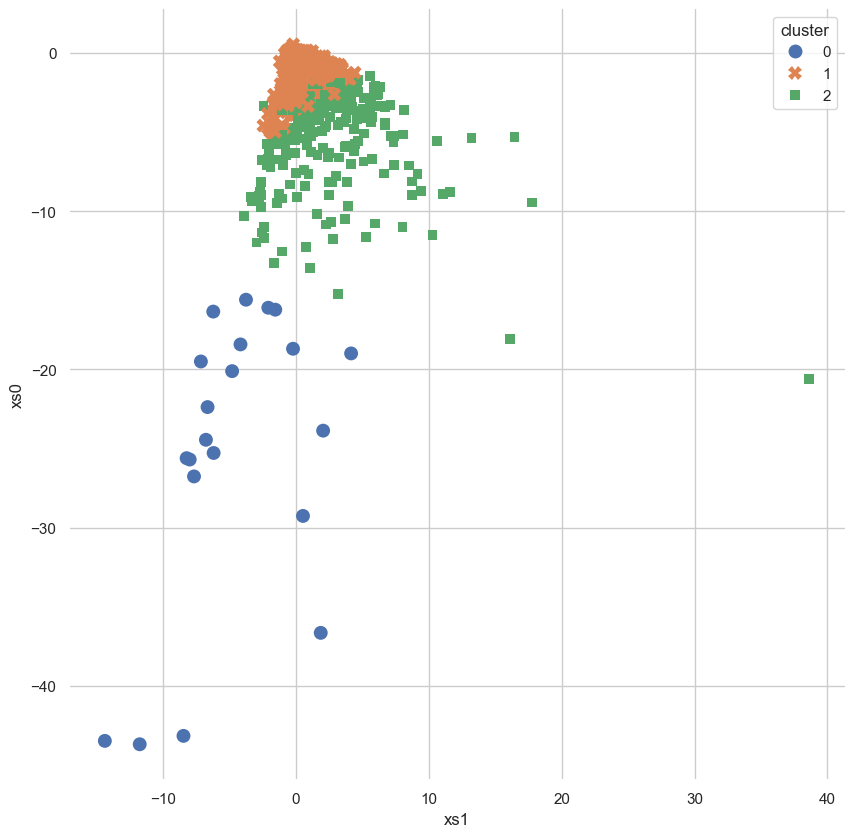

In [249]:
%pip install seaborn

from pyspark.ml.feature import PCA
pca = PCA(k=2, inputCol="scaledFeatures", outputCol="pcaFeatures")
model = pca.fit(predictor3)

result = model.transform(predictor3).select('seller_id', 'prediction', "pcaFeatures")
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

df_temp = result.withColumn("xs", vector_to_array("pcaFeatures")) \
    .select(["seller_id", "prediction", col("xs")[0].alias("xs0"), col("xs")[1].alias("xs1")]) \
    .withColumnRenamed('prediction', 'cluster')
df_temp = df_temp.toPandas()
df_temp['cluster'] = df_temp['cluster'].astype('category')
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 10))
sns.despine(f, left=True, bottom=True)

sns.scatterplot(x='xs1', y='xs0',
                hue="cluster",
                style="cluster",
                linewidth=0,
                s=100,
                data=df_temp, ax=ax)


<!-- Cluster Profiling -->

In [250]:
# Use predictor3 as the Spark DataFrame with k=3 clustering results
# Convert to pandas for groupby/describe
df3_pd = predictor3.toPandas()

# Use lowercase column names as in predictor3
df3_pd.groupby('prediction')[['qtd_order', 'number_of_products', 'qtd_product_order', 'number_of_buyers', 'sale_value', 'ticket_size',
 'recency', 'days_delay_delivery', 'frequency','review_score']].describe()

# Using k=3 in Spark’s native K-means clustering, the number of orders has a great influence on the separation of sellers from the majority group (prediction=0) and the most qualified group (prediction=2). Below, the detailed profile of the groups:

# In general, profiles can be ordered as follows, considering the general quality of the profile and the importance of the seller to Olist:
# Prediction=2 > Prediction=1 > Prediction=0

display(df3_pd[['prediction','qtd_order']])
display(df3_pd[['prediction','number_of_products']])
display(df3_pd[['prediction','qtd_product_order']])
display(df3_pd[['prediction','number_of_buyers']])
display(df3_pd[['prediction','sale_value']])
display(df3_pd[['prediction','ticket_size']])
display(df3_pd[['prediction','recency']])
display(df3_pd[['prediction','days_delay_delivery']])
display(df3_pd[['prediction','frequency']])
display(df3_pd[['prediction','review_score']])

# For Spark groupby by prediction and seller_state
df_temp = predictor3.groupBy('prediction','seller_state').count()
display(df_temp.orderBy('seller_state','prediction'))

predictor3.createOrReplaceTempView("df3")
df_seller_state = spark.sql("SELECT seller_state, seller_state_index FROM df3")


,prediction,qtd_order
0,1,3
1,1,200
2,1,1
3,1,50
4,1,1
...,...,...
3081,1,1
3082,1,18
3083,1,14
3084,1,59


,prediction,number_of_products
0,1,3
1,1,200
2,1,1
3,1,50
4,1,1
...,...,...
3081,1,1
3082,1,18
3083,1,14
3084,1,59


,prediction,qtd_product_order
0,1,1.0
1,1,1.0
2,1,1.0
3,1,1.0
4,1,1.0
...,...,...
3081,1,1.0
3082,1,1.0
3083,1,1.0
3084,1,1.0


,prediction,number_of_buyers
0,1,3
1,1,200
2,1,1
3,1,50
4,1,1
...,...,...
3081,1,1
3082,1,18
3083,1,14
3084,1,59


,prediction,sale_value
0,1,2748.06
1,1,28534.73
2,1,267.94
3,1,1885.85
4,1,139.38
...,...,...
3081,1,79.52
3082,1,2439.23
3083,1,2259.55
3084,1,11537.78


...

,prediction,recency
0,1,320
1,1,53
2,1,27
3,1,144
4,1,262
...,...,...
3081,1,72
3082,1,15
3083,1,112
3084,1,8


,prediction,days_delay_delivery
0,1,-16.333333
1,1,-12.882051
2,1,0.000000
3,1,-8.000000
4,1,-27.000000
...,...,...
3081,1,0.000000
3082,1,-12.388889
3083,1,-8.357143
3084,1,-11.196429


,prediction,frequency
0,1,0.263157894737
1,1,10.416666666667
2,1,1.111111111111
3,1,4.237288135593
4,1,0.114503821164
...,...,...
3081,1,0.416666666667
3082,1,0.987202943093
3083,1,1.242603513532
3084,1,4.359606018710


,prediction,review_score
0,1,3.666667
1,1,3.820000
2,1,1.000000
3,1,3.880000
4,1,5.000000
...,...,...
3081,1,1.000000
3082,1,4.333333
3083,1,3.785714
3084,1,3.576271


DataFrame[prediction: int, seller_state: string, count: bigint]

<!-- Analysis of Clusters Kmeans SKlearn (k=3) -->

In [251]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Use df6 and input_cols, which are already defined and available
features_df = VectorAssembler(inputCols=input_cols, outputCol='features').transform(df6)

scaler = StandardScaler(inputCol='features', outputCol='scaledFeatures')
scaled_df = scaler.fit(features_df).transform(features_df)
scaled_df.show()

+---------+------------------+-----------------+----------------+------------------+------------------+--------------------+-------------------+-------+-------------------+--------------------+---------+-------+--------+--------+--------+-------+-----------+----------+------------------+--------------------------+----------------+---+---------------------+-----+----+----+--------------+----------------------+--------------+---------------+-----------------+------------------+----------+---------+---------------------+--------------+-------------------------------+-------------------------+-------------------------+----------+------------------------+-----------------------+-------------------+------+------------+-----------+------------------------+-------------------------+---------------------+-------------+-------------+-----------------------+----------------------+---------------+-------+----+----------+-----------------+---------------+---------------------+----------------------

<Axes: xlabel='xs1', ylabel='xs0'>

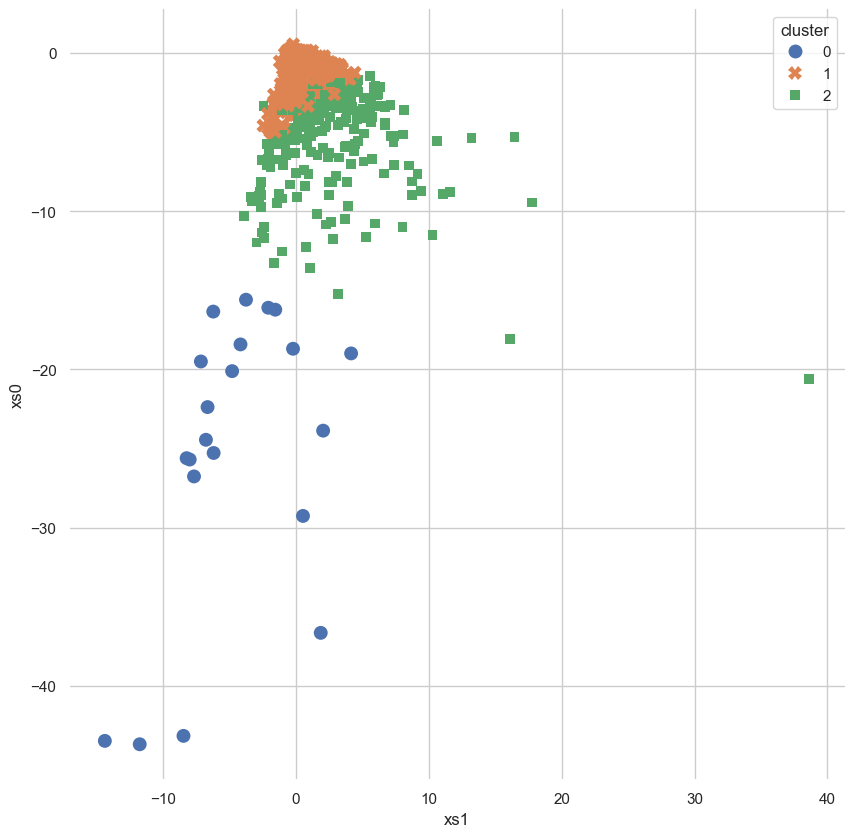

In [252]:
from pyspark.ml.feature import PCA
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col
import seaborn as sns
import matplotlib.pyplot as plt

# Use predictor3, which already has 'seller_id', 'prediction', and 'scaledFeatures'
pca = PCA(k=2, inputCol="scaledFeatures", outputCol="pcaFeatures")
model = pca.fit(predictor3)

result = model.transform(predictor3).select('seller_id', 'prediction', "pcaFeatures")

df_temp = result.withColumn("xs", vector_to_array("pcaFeatures")) \
    .select(["seller_id", "prediction", col("xs")[0].alias("xs0"), col("xs")[1].alias("xs1")]) \
    .withColumnRenamed('prediction', 'cluster')
df_temp = df_temp.toPandas()
df_temp['cluster'] = df_temp['cluster'].astype('category')

sns.set(style="whitegrid")
f, ax = plt.subplots(figsize=(10, 10))
sns.despine(f, left=True, bottom=True)

sns.scatterplot(
    x='xs1', y='xs0',
    hue="cluster",
    style="cluster",
    linewidth=0,
    s=100,
    data=df_temp, ax=ax
)


In [253]:
# Use predictor3 for Spark DataFrame and df3_pd for pandas DataFrame

# Convert to pandas for groupby/describe
df3_pd = predictor3.toPandas()
df3_pd.groupby('prediction')[["qtd_order", "number_of_products", "qtd_product_order", "number_of_buyers", "sale_value", "ticket_size", "recency", "days_delay_delivery", "frequency"]].describe()

# In general, profiles can be ordered as follows, considering the general quality of the profile and the importance of the seller to Olist:
# Prediction=2 > Prediction=1 > Prediction=0

display(df3_pd[['prediction','qtd_order']])
display(df3_pd[['prediction','number_of_products']])
display(df3_pd[['prediction','qtd_product_order']])
display(df3_pd[['prediction','number_of_buyers']])
display(df3_pd[['prediction','sale_value']])
display(df3_pd[['prediction','ticket_size']])
display(df3_pd[['prediction','recency']])
display(df3_pd[['prediction','days_delay_delivery']])
display(df3_pd[['prediction','frequency']])
display(df3_pd[['prediction','review_score']])

# For Spark groupby by prediction and seller_state
df_temp = predictor3.groupBy('prediction','seller_state').count()
display(df_temp.orderBy('seller_state','prediction'))



,prediction,qtd_order
0,1,3
1,1,200
2,1,1
3,1,50
4,1,1
...,...,...
3081,1,1
3082,1,18
3083,1,14
3084,1,59


,prediction,number_of_products
0,1,3
1,1,200
2,1,1
3,1,50
4,1,1
...,...,...
3081,1,1
3082,1,18
3083,1,14
3084,1,59


,prediction,qtd_product_order
0,1,1.0
1,1,1.0
2,1,1.0
3,1,1.0
4,1,1.0
...,...,...
3081,1,1.0
3082,1,1.0
3083,1,1.0
3084,1,1.0


,prediction,number_of_buyers
0,1,3
1,1,200
2,1,1
3,1,50
4,1,1
...,...,...
3081,1,1
3082,1,18
3083,1,14
3084,1,59


,prediction,sale_value
0,1,2748.06
1,1,28534.73
2,1,267.94
3,1,1885.85
4,1,139.38
...,...,...
3081,1,79.52
3082,1,2439.23
3083,1,2259.55
3084,1,11537.78


...

,prediction,recency
0,1,320
1,1,53
2,1,27
3,1,144
4,1,262
...,...,...
3081,1,72
3082,1,15
3083,1,112
3084,1,8


,prediction,days_delay_delivery
0,1,-16.333333
1,1,-12.882051
2,1,0.000000
3,1,-8.000000
4,1,-27.000000
...,...,...
3081,1,0.000000
3082,1,-12.388889
3083,1,-8.357143
3084,1,-11.196429


,prediction,frequency
0,1,0.263157894737
1,1,10.416666666667
2,1,1.111111111111
3,1,4.237288135593
4,1,0.114503821164
...,...,...
3081,1,0.416666666667
3082,1,0.987202943093
3083,1,1.242603513532
3084,1,4.359606018710


,prediction,review_score
0,1,3.666667
1,1,3.820000
2,1,1.000000
3,1,3.880000
4,1,5.000000
...,...,...
3081,1,1.000000
3082,1,4.333333
3083,1,3.785714
3084,1,3.576271


DataFrame[prediction: int, seller_state: string, count: bigint]

25/06/13 11:49:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/06/13 11:49:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/06/13 11:49:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/06/13 11:49:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/06/13 11:49:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


<Axes: xlabel='xs1', ylabel='xs0'>

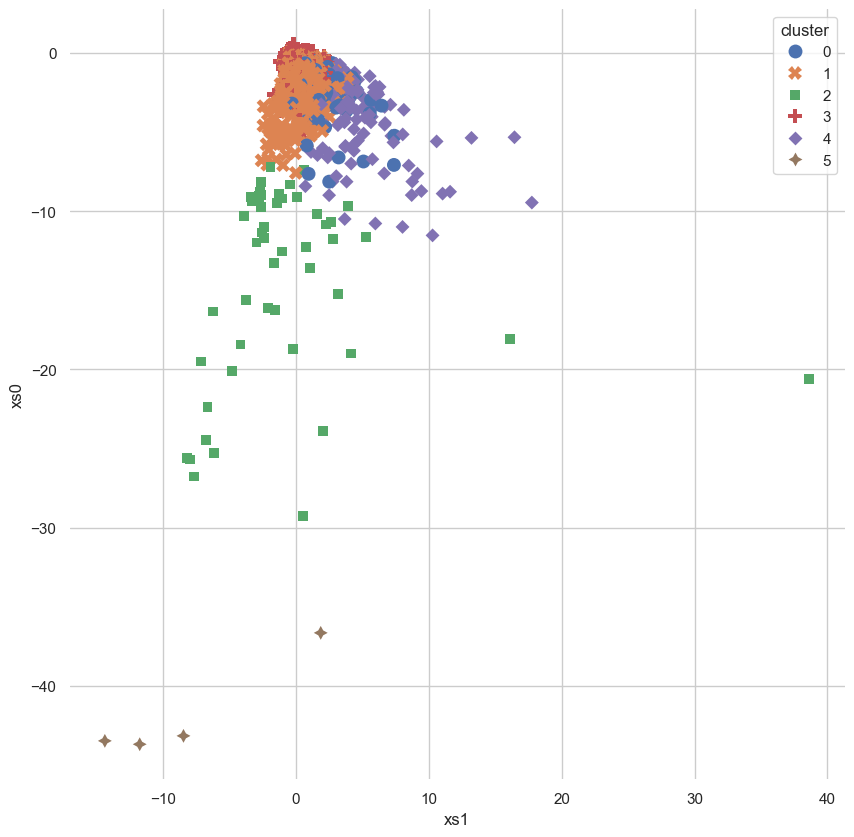

In [254]:
# Use predictokml DataFrame, which contains all required columns including 'km6'
from pyspark.sql.functions import col

# Rename 'km6' to 'prediction'
df3 = predictokml.withColumnRenamed('km6', 'prediction')

from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.functions import vector_to_array

# Use the correct input_cols list (already defined)
assembler = VectorAssembler(inputCols=input_cols, outputCol='features')
df3 = assembler.transform(df3)

scaler = StandardScaler(inputCol='features', outputCol='scaledFeatures')
df3 = scaler.fit(df3).transform(df3)

# Add a unique row number as SELLER_ID for plotting (if needed)
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
w = Window.orderBy("qtd_order")
df3 = df3.withColumn("SELLER_ID", row_number().over(w))

# PCA to 2 components
pca = PCA(k=2, inputCol="scaledFeatures", outputCol="pcaFeatures")
model = pca.fit(df3)
result = model.transform(df3).select('SELLER_ID', 'prediction', "pcaFeatures")

# Convert PCA vector to columns for plotting
df_temp = result.withColumn("xs", vector_to_array("pcaFeatures")) \
    .select(["SELLER_ID", "prediction", col("xs")[0].alias("xs0"), col("xs")[1].alias("xs1")]) \
    .withColumnRenamed('prediction', 'cluster')
df_temp = df_temp.toPandas()
df_temp['cluster'] = df_temp['cluster'].astype('category')

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 10))
sns.despine(f, left=True, bottom=True)

sns.scatterplot(
    x='xs1', y='xs0',
    hue="cluster",
    style="cluster",
    linewidth=0,
    s=100,
    data=df_temp, ax=ax
)


In [255]:
# Use df6, which contains all required columns, and add the 'prediction' column from 'km6'
from pyspark.sql.functions import col

df6_with_pred = df6.withColumnRenamed('km6', 'prediction')

# Convert to pandas for groupby/describe
df_temp = df6_with_pred.toPandas()
df_temp.groupby('prediction')[['qtd_order', 'number_of_products', 'qtd_product_order', 'number_of_buyers', 'sale_value', 'ticket_size',
 'recency', 'days_delay_delivery', 'frequency','review_score']].describe()

display(df6_with_pred.select('prediction','qtd_order'))
display(df6_with_pred.select('prediction','number_of_products'))
display(df6_with_pred.select('prediction','qtd_product_order'))
display(df6_with_pred.select('prediction','number_of_buyers'))
display(df6_with_pred.select('prediction','sale_value'))
display(df6_with_pred.select('prediction','ticket_size'))
display(df6_with_pred.select('prediction','recency'))
display(df6_with_pred.select('prediction','days_delay_delivery'))
display(df6_with_pred.select('prediction','frequency'))
display(df6_with_pred.select('prediction','review_score'))

# For Spark groupby by prediction only (since 'seller_state' does not exist in df6)
df_temp_grouped = df6_with_pred.groupBy('prediction').count()
display(df_temp_grouped.orderBy('prediction'))



DataFrame[prediction: bigint, qtd_order: bigint]

DataFrame[prediction: bigint, number_of_products: bigint]

DataFrame[prediction: bigint, qtd_product_order: double]

DataFrame[prediction: bigint, number_of_buyers: bigint]

DataFrame[prediction: bigint, sale_value: double]

...

DataFrame[prediction: bigint, days_delay_delivery: double]

DataFrame[prediction: bigint, frequency: decimal(38,18)]

DataFrame[prediction: bigint, review_score: double]

DataFrame[prediction: bigint, count: bigint]

25/06/14 10:02:39 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 906611 ms exceeds timeout 120000 ms
25/06/14 10:02:39 WARN SparkContext: Killing executors is not supported by current scheduler.
25/06/14 10:02:45 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at o